## Tranining Model
In this notebook, we will train and experiment with different machine learning, AI, and Statistical methods for classifying anomalous and normal packets. The result from this training will be used as weight for the application demonstration, which can be used in real-time for analyzing anomalous packets in the network through python scapy + web application under `/app` folder.

In [1]:
!pip install -r requirements.txt

In [2]:
from scipy.io import arff
import pandas as pd

# to avoid base 10 exponents
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

arff_file = arff.loadarff("dataset/KDDTrain+.arff")
train_dataset_df = pd.DataFrame(arff_file[0])

# decode the bytes loaded from scipy (default behavior)
categorical_cols = train_dataset_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    try:
        train_dataset_df[col] = train_dataset_df[col].str.decode('utf-8')

    # exception triggers when the column is already a string
    except AttributeError:
        continue

# normalize the integer columns from float64 -> integer
numeric_real_cols = [
    "duration",
    "src_bytes",
    "dst_bytes",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "land",
    "logged_in",
    "is_host_login",
    "is_guest_login"
]

for numeric_columns in numeric_real_cols:
    train_dataset_df[numeric_columns] = pd.to_numeric(train_dataset_df[numeric_columns])


In [3]:
arff_file = arff.loadarff("dataset/KDDTest+.arff")
test_dataset_df = pd.DataFrame(arff_file[0])

for col in categorical_cols:
    try:
        test_dataset_df[col] = test_dataset_df[col].str.decode('utf-8')

    # exception triggers when the column is already a string
    except AttributeError:
        continue


In [4]:
from sklearn.preprocessing import LabelEncoder

# training dataset
x_train = train_dataset_df.drop(columns=['class'])
y_train = LabelEncoder().fit_transform(train_dataset_df['class'])

# testing dataset
x_test = test_dataset_df.drop(columns=['class'])
y_test = LabelEncoder().fit_transform(test_dataset_df['class'])

# class preprpocessing from string label to numerical
for col in x_train.select_dtypes(include=["object", "str"]).columns:
    x_train[col] = LabelEncoder().fit_transform(x_train[col].astype(str))


for col in x_test.select_dtypes(include=["object", "str"]).columns:
    x_test[col] = LabelEncoder().fit_transform(x_test[col].astype(str))


## Straightforward Approach
The following training below uses a straightforward approach or simply training the data directly to the model, the purpose of this is for us to have a high-level overview which model could potentially work very well for the dataset

In [5]:
# after experimenting with different scaling strategies
# the StandardScaler got the best performance out of all

# note for devs: standard-scaler is very dependent on the dataset since it uses the z-score
# so in production environment with high value of outliers, this might perform poorly

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [6]:
from sklearn.linear_model import LogisticRegression

# logistic regression training
logistic_regression_model = LogisticRegression(max_iter=500, random_state=67)
logistic_regression_model.fit(x_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",67
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbf

In [7]:
from sklearn.tree import DecisionTreeClassifier

# current highest accuracy config is max_depth=6
decision_tree_model = DecisionTreeClassifier(max_depth=6, random_state=67)
decision_tree_model.fit(x_scaled, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",67
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [8]:
from sklearn.ensemble import RandomForestClassifier

random_forest_classifier = RandomForestClassifier(max_depth=6, random_state=67)
random_forest_classifier.fit(x_scaled, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",67
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap:

### Confusion Matrix Display
The following are the confusion matrix of each models from the actual test dataset 

In [9]:
import time

t_logistic = time.perf_counter()
y_pred_logistic = logistic_regression_model.predict(x_test_scaled)
t_logistic = time.perf_counter() - t_logistic

t_decision = time.perf_counter()
y_pred_decision = decision_tree_model.predict(x_test_scaled)
t_decision = time.perf_counter() - t_decision

t_random_forest = time.perf_counter()
y_pred_random_forest = random_forest_classifier.predict(x_test_scaled)
t_random_forest = time.perf_counter() - t_random_forest

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import matplotlib.pyplot as plt

confusion_logistic = confusion_matrix(y_test, y_pred_logistic)
confusion_decision = confusion_matrix(y_test, y_pred_decision)
confusion_pred_random_forest = confusion_matrix(y_test, y_pred_random_forest)

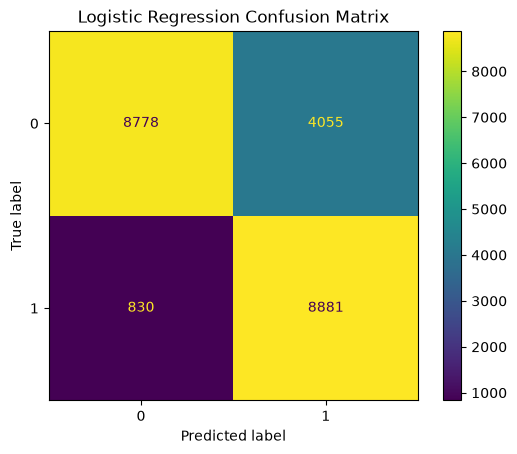

              precision    recall  f1-score   support

           0       0.91      0.68      0.78     12833
           1       0.69      0.91      0.78      9711

    accuracy                           0.78     22544
   macro avg       0.80      0.80      0.78     22544
weighted avg       0.82      0.78      0.78     22544

Overall Accuracy: 0.7833126330731015
Time Prediction: 0.008312057000011919


In [11]:
logistic_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_logistic,
    display_labels=logistic_regression_model.classes_
)

logistic_display.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred_logistic))
print("Overall Accuracy:", accuracy_score(y_test, y_pred_logistic))
print("Time Prediction:", t_logistic)

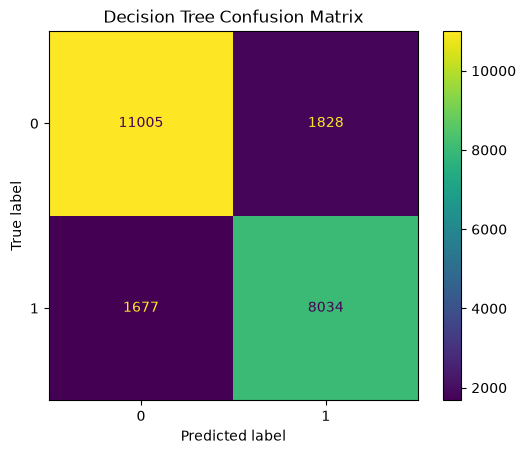

              precision    recall  f1-score   support

           0       0.87      0.86      0.86     12833
           1       0.81      0.83      0.82      9711

    accuracy                           0.84     22544
   macro avg       0.84      0.84      0.84     22544
weighted avg       0.84      0.84      0.84     22544

Overall Accuracy: 0.8445262597586941
Time Prediction: 0.008107323000103861


In [12]:
decision_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_decision,
    display_labels=decision_tree_model.classes_
)

decision_display.plot()

plt.title("Decision Tree Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred_decision))
print("Overall Accuracy:", accuracy_score(y_test, y_pred_decision))
print("Time Prediction:", t_decision)

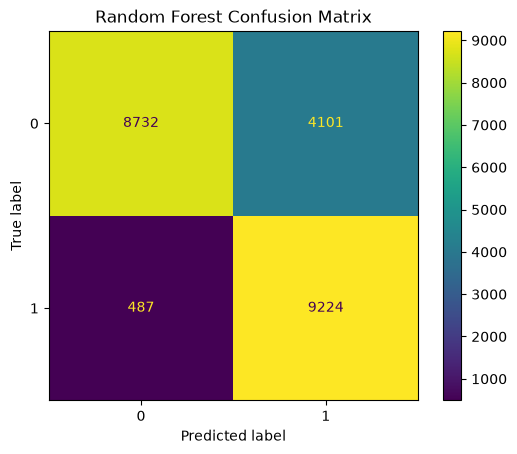

              precision    recall  f1-score   support

           0       0.95      0.68      0.79     12833
           1       0.69      0.95      0.80      9711

    accuracy                           0.80     22544
   macro avg       0.82      0.82      0.80     22544
weighted avg       0.84      0.80      0.80     22544

Overall Accuracy: 0.7964868701206529
Time Prediction: 0.09172003499998027


In [13]:
random_forest_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_pred_random_forest,
    display_labels=random_forest_classifier.classes_
)

random_forest_display.plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred_random_forest))
print("Overall Accuracy:", accuracy_score(y_test, y_pred_random_forest))
print("Time Prediction:", t_random_forest)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


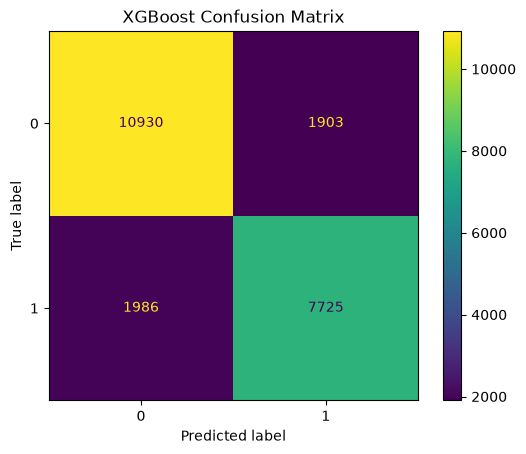

              precision    recall  f1-score   support

           0       0.85      0.85      0.85     12833
           1       0.80      0.80      0.80      9711

    accuracy                           0.83     22544
   macro avg       0.82      0.82      0.82     22544
weighted avg       0.83      0.83      0.83     22544

Overall Accuracy: 0.8274929027679205
Time Prediction: 0.009808849999899394


In [14]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=67)

param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1],
    "n_estimators": [100, 200],
    "subsample": [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_scaled, y_train)

t_xgb_model = time.perf_counter()
y_pred_voting_classifier = grid_search.predict(x_test_scaled)
t_xgb_model = time.perf_counter() - t_xgb_model


confusion_xgb = confusion_matrix(y_test, y_pred_voting_classifier)
voting_classifier_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_xgb,
    display_labels=grid_search.classes_
)

voting_classifier_display.plot()

plt.title("XGBoost Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred_voting_classifier))
print("Overall Accuracy:", accuracy_score(y_test, y_pred_voting_classifier))
print("Time Prediction:", t_xgb_model)

### Summary Report (Straightforward approach)
In the IDS design, it is more important that _anomaly_ classification has more `True Positive` matches over `False Positive` since false-positives in anomaly detection can result into a more damaging consequence. With this, it is safe to say that the `Decision Tree` might be the best candidate for anomaly classification. On the other hand, `Random Forest` would be the best candidate for classifying _normal_ packets.

Accuracy Ranking:
1. Decision Tree
2. XGBoost
3. Random Forest
4. Logistic Regression

## Additional Model Experiments
The following below contains different experiments to improve the performance of the models, this includes using ensemble and other techniques.

### Using Ensemble
The following uses ensemble for `Decision Tree` (top performing for TP classification of anomaly) and `Random Forest` (top performing for TP classification of normal packets)

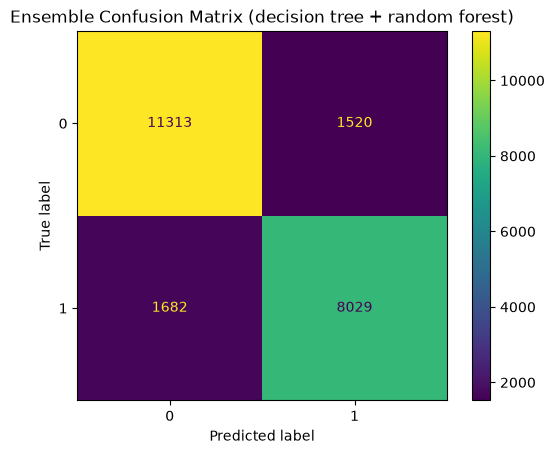

              precision    recall  f1-score   support

           0       0.87      0.88      0.88     12833
           1       0.84      0.83      0.83      9711

    accuracy                           0.86     22544
   macro avg       0.86      0.85      0.85     22544
weighted avg       0.86      0.86      0.86     22544

Overall Accuracy: 0.8579666430092264
Time Prediction: 0.0796578579997913


In [ ]:
from sklearn.ensemble import VotingClassifier

base_models = [
    ("dtr", decision_tree_model),
    ("rdf", random_forest_classifier)
]

voting_classifier = VotingClassifier(
    estimators=base_models,
    voting="soft",
)

voting_classifier.fit(x_scaled, y_train)

t_voting_classifier = time.perf_counter()
y_pred_voting_classifier = voting_classifier.predict(x_test_scaled)
t_voting_classifier = time.perf_counter() - t_voting_classifier

confusion_pred_voting_class = confusion_matrix(y_test, y_pred_voting_classifier)
voting_classifier_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_pred_voting_class,
    display_labels=voting_classifier.classes_
)

voting_classifier_display.plot()

plt.title("Ensemble Confusion Matrix (decision tree + random forest)")
plt.show()

print(classification_report(y_test, y_pred_voting_classifier))
print("Overall Accuracy:", accuracy_score(y_test, y_pred_voting_classifier))
print("Time Prediction:", t_voting_classifier)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


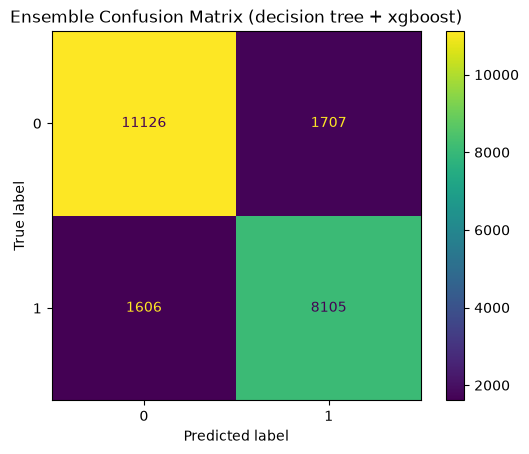

              precision    recall  f1-score   support

           0       0.87      0.87      0.87     12833
           1       0.83      0.83      0.83      9711

    accuracy                           0.85     22544
   macro avg       0.85      0.85      0.85     22544
weighted avg       0.85      0.85      0.85     22544

Overall Accuracy: 0.853042938254081
Time Prediction: 0.015182778000053077


In [24]:
from sklearn.ensemble import VotingClassifier

base_models = [
    ("dtr", decision_tree_model),
    ("xdg", grid_search)
]

voting_classifier = VotingClassifier(
    estimators=base_models,
    voting="soft",
)

voting_classifier.fit(x_scaled, y_train)

t_voting_classifier = time.perf_counter()
y_pred_voting_classifier = voting_classifier.predict(x_test_scaled)
t_voting_classifier = time.perf_counter() - t_voting_classifier

confusion_pred_voting_class = confusion_matrix(y_test, y_pred_voting_classifier)
voting_classifier_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_pred_voting_class,
    display_labels=voting_classifier.classes_
)

voting_classifier_display.plot()

plt.title("Ensemble Confusion Matrix (decision tree + xgboost)")
plt.show()

print(classification_report(y_test, y_pred_voting_classifier))
print("Overall Accuracy:", accuracy_score(y_test, y_pred_voting_classifier))
print("Time Prediction:", t_voting_classifier)

We can observe here that ensemble method increases the overall accuracy of the model, the second ensemble (xdg + dtr) has shown promising result when it comes to detecting anomalous packets. In production environments, this would be the ideal to select since FPs for anomalous packets has damaging consequence over FPs of normal packets.

In [27]:
# export best model class state so that i can load it for later
import pickle

with open('ml_models/voting_classifier.pkl', 'wb') as file:
    pickle.dump(voting_classifier, file)
